In [ ]:
#this script uses built in CI calcuation fucntion from statsmodel 

In [2]:
from ALLCools.mcds import MCDS
import pandas as pd
import anndata
from scipy.sparse import csr_matrix

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
base = "/quobyte/lasallegrp/Ensi/project/oocytes-macaque/allcools/allcools-subsampled/embryo/allc_PEEO_sub/"
mcds_paths = base + '/genebody_frac.mcds/'
cell_meta_path = 'L1_clustering_labels.csv'
cluster_col = 'L1'

obs_dim = 'cell'
var_dim = 'genebody'
mc_type = 'CGN'

In [5]:
cell_metaa = pd.read_csv(f"{base}metadata_allco.csv", index_col=0)



cell_metaa['AnimalID'] = cell_metaa['Animal ID'] 
cell_metaa = cell_metaa[cell_metaa['Type'] == "EO"]
cell_metaa

,Animal ID,Group,Sample Name,Type,# Read,% mCpG,Group.1,Path,AnimalID
SampleID,,,,,,,,,
4520845054EO2NC8E7S,45208,Stressed,45208_45054_EO2_NC8_E7_1_val_1,EO,600000,0.709,Stressed,mv 45208_45054_EO2_NC8_E7_1_val_1_bismark_bt2_...,45208
4247345061EO1NC8O4S,42473,Stressed,42473_45061_EO1_NC8_O4_1_val_1,EO,1500000,0.670,Stressed,mv 42473_45061_EO1_NC8_O4_1_val_1_bismark_bt2_...,42473
4520845054EO3NC8F7S,45208,Stressed,45208_45054_EO3_NC8_F7_1_val_1,EO,1800000,0.724,Stressed,mv 45208_45054_EO3_NC8_F7_1_val_1_bismark_bt2_...,45208
4305145068EO1NC8M5S,43051,Stressed,43051_45068_EO1_NC8_M5_1_val_1,EO,2100000,0.671,Stressed,mv 43051_45068_EO1_NC8_M5_1_val_1_bismark_bt2_...,43051
4211145019EOoNC8M4C,42111,Control,42111_45019_EOo_NC8_M4_1_val_1,EO,4800000,0.488,Control,mv 42111_45019_EOo_NC8_M4_1_val_1_bismark_bt2_...,42111
4520845054EO5NC8H7S,45208,Stressed,45208_45054_EO5_NC8_H7_1_val_1,EO,5900000,0.638,Stressed,mv 45208_45054_EO5_NC8_H7_1_val_1_bismark_bt2_...,45208
4305145068EO3NC8O5S,43051,Stressed,43051_45068_EO3_NC8_O5_1_val_1,EO,6100000,0.718,Stressed,mv 43051_45068_EO3_NC8_O5_1_val_1_bismark_bt2_...,43051
4129945019EO6NC8H2S,41299,Stressed,41299_45019_EO6_NC8_H2_1_val_1,EO,7200000,0.699,Stressed,mv 41299_45019_EO6_NC8_H2_1_val_1_bismark_bt2_...,41299
4520845054EO4NC8G7S,45208,Stressed,45208_45054_EO4_NC8_G7_1_val_1,EO,8600000,0.502,Stressed,mv 45208_45054_EO4_NC8_G7_1_val_1_bismark_bt2_...,45208


gene_meta = pd.read_csv('../../GeneMetadata_withGeneName_corrected.csv')
gene_meta["Gene"] = gene_meta["gene_id"]
gene_meta

In [6]:
mcds = MCDS.open(mcds_paths)
mcds['cell'].values


array(['4129945019EO2NC8D2S', '4129945019EO3NC8E2S',
       '4129945019EO4NC8F2S', '4129945019EO5NC8G2S',
       '4129945019EO6NC8H2S', '4129945019EO8NC8J2S',
       '4211145019EOoNC8M4C', '4247345061EO1NC8O4S',
       '4305145068EO1NC8M5S', '4305145068EO3NC8O5S',
       '4520845054BL2NC16J7S', '4520845054BL3NC16K7S',
       '4520845054BL4NC16L7S', '4520845054BL5NC16M7S',
       '4520845054BL6NC16N7S', '4520845054EO1NC8D7S',
       '4520845054EO2NC8E7S', '4520845054EO3NC8F7S',
       '4520845054EO4NC8G7S', '4520845054EO5NC8H7S'], dtype='<U20')

In [7]:
    # Filter metadata to ensure cells align with MCDS cells
cell_meta = cell_metaa[cell_metaa.index.isin(mcds['cell'].values)]
mcds = mcds.sel(cell=cell_meta.index)
cell_meta.index

Index(['4520845054EO2NC8E7S', '4247345061EO1NC8O4S', '4520845054EO3NC8F7S',
       '4305145068EO1NC8M5S', '4211145019EOoNC8M4C', '4520845054EO5NC8H7S',
       '4305145068EO3NC8O5S', '4129945019EO6NC8H2S', '4520845054EO4NC8G7S',
       '4520845054EO1NC8D7S', '4129945019EO8NC8J2S', '4129945019EO5NC8G2S',
       '4129945019EO2NC8D2S', '4129945019EO4NC8F2S', '4129945019EO3NC8E2S'],
      dtype='object', name='SampleID')

In [8]:


def convert_mcds_to_anndata(mcds_path, cell_meta, mc_type='CGN'):
    # Load the MCDS data and metadata
    mcds = MCDS.open(mcds_paths)

    
    # Filter metadata to ensure cells align with MCDS cells
    cell_meta = cell_metaa[cell_metaa.index.isin(mcds['cell'].values)]
    mcds = mcds.sel(cell=cell_meta.index)
    
    # Extract methylation fraction data directly from `genebody_da_frac`
    methylation_data = mcds['genebody_da_frac'].sel(mc_type=mc_type).values

    # Convert methylation data to a sparse matrix to save memory
    methylation_data = csr_matrix(methylation_data)

    # Create AnnData with methylation fraction matrix as `X`
    adata = anndata.AnnData(X=methylation_data)
    
    # Set cell-level metadata
    adata.obs = cell_meta
    
    # Set gene-level metadata
    adata.var = pd.DataFrame({
        'gene_id': mcds['genebody'].values,
        'chrom': mcds['genebody_chrom'].values,
        'start': mcds['genebody_start'].values,
        'end': mcds['genebody_end'].values
    }, index=mcds['genebody'].values)
    
    # Optionally, add the methylation fraction as a layer if needed for future analysis
    adata.layers['methylation_fraction'] = methylation_data

    return adata



In [9]:
#Convert MCDS to AnnData
adata = convert_mcds_to_anndata(mcds_paths, cell_metaa, mc_type='CGN')
#adata.write_h5ad("embryo_only/adataFromgenebodyFrac_mCG_Embryoonly.h5ad")
#adata = anndata.read_h5ad(f"{base}embryo_only/adataFromgenebodyFrac_mCG_Embryoonly.h5ad")
adata.obs_names

Index(['4520845054EO2NC8E7S', '4247345061EO1NC8O4S', '4520845054EO3NC8F7S',
       '4305145068EO1NC8M5S', '4211145019EOoNC8M4C', '4520845054EO5NC8H7S',
       '4305145068EO3NC8O5S', '4129945019EO6NC8H2S', '4520845054EO4NC8G7S',
       '4520845054EO1NC8D7S', '4129945019EO8NC8J2S', '4129945019EO5NC8G2S',
       '4129945019EO2NC8D2S', '4129945019EO4NC8F2S', '4129945019EO3NC8E2S'],
      dtype='object', name='SampleID')

In [10]:
adata.obs_names = adata.obs_names.astype(str)


In [11]:
adataembryo = adata
adataembryo.obs_names

Index(['4520845054EO2NC8E7S', '4247345061EO1NC8O4S', '4520845054EO3NC8F7S',
       '4305145068EO1NC8M5S', '4211145019EOoNC8M4C', '4520845054EO5NC8H7S',
       '4305145068EO3NC8O5S', '4129945019EO6NC8H2S', '4520845054EO4NC8G7S',
       '4520845054EO1NC8D7S', '4129945019EO8NC8J2S', '4129945019EO5NC8G2S',
       '4129945019EO2NC8D2S', '4129945019EO4NC8F2S', '4129945019EO3NC8E2S'],
      dtype='object', name='SampleID')

In [12]:
adataoocyte = anndata.read_h5ad("/quobyte/lasallegrp/Ensi/project/oocytes-macaque/allcools/allcools-subsampled/alloocytes/results-pooled/hdWGBS/adataFromgenebodyFrac_mCG.h5ad")
adataoocyte.obs_names

Index(['4146045001PO3NC4G4C', '4129944963PO2NC4M1S', '4520844650PO1NC5A7S',
       '4146045001PO2NC3F4C', '4520844650PO2NC3B7S', '3905345005PO1NC2I1S',
       '4129944963PO1NC3N1S', '4211144957PO1NC3K4C', '4660644938PO2NC3A10C',
       '4139144923PO4NC4K3C', '4598244908PO1NC3J8C', '4598244908PO2NC4K8C',
       '4566944964PO2NC4C7C', '4129944963PO3NC3O1S', '4139144923PO3NC5J3C',
       '4566944964PO3NC3D8C', '4265145042PO3NC4G5S', '4598245001PO2NC4F8C',
       '4499445005PO2NC3C5C', '4660644993PO2NC5D10C', '4566944964PO4NC3E8C',
       '4660644938PO3NC5B10C', '4636344664PO1NC5L9C', '4566944700PO1NC5O8C',
       '4636344914PO1NC4H9C', '4265145042PO2NC4N4S', '4660644993PO3NC5E10C',
       '4211144957PO2NC3L4C', '3889744700PO1NC5D1S', '4265145042PO1NC3E5S',
       '4660644993PO4NC5F10C', '4146044643PO3NC5A4C', '4146045001PO1NC5E4C',
       '4139144650PO1NC4F3C', '4139144650PO2NC4G3C', '4520844650PO3NC5C8S',
       '4566944700PO2NC5P8C', '4146044643PO1NC5O3C', '4456444991PO1NC3H6C',
       

In [13]:
adataembryo.layers['methylation_fraction'].data


array([1.251523  , 1.2453799 , 1.1828555 , ..., 0.42035067, 1.1652611 ,
       1.        ], dtype=float32)

In [14]:
# 1- per group - bulit in function 
# 1- per group - built-in function
# ============================================================
# Title: Group comparison methylation figure using built-in Welch test (statsmodels)
# What changed/added:
# 1) Replaced manual Welch t-test + CI with statsmodels CompareMeans
# 2) Handles non-estimable comparisons with NaN
# 3) Added number of animals to delta-panel subtitles
# 4) Made significance stars larger and closer to bars
# 5) Saves stats table and figure files
# ============================================================

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from statsmodels.stats.multitest import multipletests
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['savefig.transparent'] = True
matplotlib.rcParams['path.simplify'] = False

# ── Step 1: Define transcription factors ──
highlight_tfs = [
    'BARHL2', 'FOXA2', 'SOX18', 'HOXC12', 'ASCL4', 'LHX5', 'EN1',
    'HOXD12', 'HOXD1', 'FEV', 'LHX3', 'DLX3', 'HOXB13', 'GSX1',
    'CDX2', 'ZIC1', 'ZNF174', 'PURB', 'HOXA7', 'VGLL2', 'CITED2',
    'TCF19', 'FOXQ1', 'MYC', 'NKX1-2', 'FLI1', 'UTF1', 'ZIC3'
]
highlight_tfs_set = set(highlight_tfs)

# ── Step 2: Load gene list ──
genes_df = pd.read_csv("../pooledoocytes/mCG_genenames_coords_withlifted.csv", sep=",")
genes_df.columns = ["gene_id", "chr", "start", "end", "genename"]
target_genes = genes_df['gene_id'].dropna().unique()
gene_id_to_name = (
    genes_df.dropna(subset=['genename'])
    .set_index("gene_id")["genename"]
    .to_dict()
)

# ── Step 3: Filter groups ──
adata_oocyte_control  = adataoocyte[adataoocyte.obs['Group'] == 'Control'].copy()
adata_oocyte_stressed = adataoocyte[adataoocyte.obs['Group'] == 'Stressed'].copy()
adata_embryo_stressed = adataembryo[adataembryo.obs['Group'] == 'Stressed'].copy()

# ── Count cells and animals for titles ──
n_ctrl_ooc_cells = adata_oocyte_control.shape[0]
n_str_ooc_cells  = adata_oocyte_stressed.shape[0]
n_str_emb_cells  = adata_embryo_stressed.shape[0]

n_ctrl_ooc_animals = adata_oocyte_control.obs['AnimalID'].nunique()
n_str_ooc_animals  = adata_oocyte_stressed.obs['AnimalID'].nunique()
n_str_emb_animals  = adata_embryo_stressed.obs['AnimalID'].nunique()

# ── Step 4: Filter each object to target genes only ──
target_genes_set = set(target_genes)

def subset_to_targets(adata, target_genes_set):
    keep = adata.var['gene_id'].isin(target_genes_set).values
    return adata[:, keep].copy()

adata_oocyte_control  = subset_to_targets(adata_oocyte_control, target_genes_set)
adata_oocyte_stressed = subset_to_targets(adata_oocyte_stressed, target_genes_set)
adata_embryo_stressed = subset_to_targets(adata_embryo_stressed, target_genes_set)

# ── Step 5: Align three adatas using only target genes ──
def align_three_targets(a1, a2, a3, target_genes):
    target_genes = [
        g for g in target_genes
        if (
            g in set(a1.var['gene_id']) and
            g in set(a2.var['gene_id']) and
            g in set(a3.var['gene_id'])
        )
    ]

    def subset_in_order(adata, ids):
        var_idx = (
            adata.var.reset_index()
            .drop_duplicates('gene_id')
            .set_index('gene_id')
        )
        return adata[:, var_idx.loc[ids]['index'].values].copy()

    return (
        subset_in_order(a1, target_genes),
        subset_in_order(a2, target_genes),
        subset_in_order(a3, target_genes),
        np.array(target_genes)
    )

adata_ctrl, adata_str_ooc, adata_str_emb, common_gene_ids = align_three_targets(
    adata_oocyte_control,
    adata_oocyte_stressed,
    adata_embryo_stressed,
    target_genes
)

# ── Step 6: Extract dense matrices ──
def to_dense(adata):
    X = adata.layers['methylation_fraction']
    return X.toarray() if hasattr(X, 'toarray') else np.array(X)

X_ctrl    = to_dense(adata_ctrl)
X_str_ooc = to_dense(adata_str_ooc)
X_str_emb = to_dense(adata_str_emb)

# ── Step 7: Built-in Welch test + CI using statsmodels ──
def welch_statsmodels(a, b, alpha=0.05):
    """
    Returns (pval, delta_mean, ci_low, ci_high) for b - a
    using statsmodels built-in Welch test.
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]

    if len(a) == 0 or len(b) == 0:
        return np.nan, np.nan, np.nan, np.nan

    delta = np.mean(b) - np.mean(a)

    if len(a) < 2 or len(b) < 2:
        return np.nan, delta, np.nan, np.nan

    if (np.std(a, ddof=1) == 0) and (np.std(b, ddof=1) == 0):
        return 1.0, delta, delta, delta

    cm = CompareMeans(DescrStatsW(b), DescrStatsW(a))
    tstat, pval, df = cm.ttest_ind(usevar='unequal')
    ci_lo, ci_hi = cm.tconfint_diff(usevar='unequal', alpha=alpha)

    return pval, delta, ci_lo, ci_hi

n_genes = len(common_gene_ids)
results = []

for i in range(n_genes):
    gid = common_gene_ids[i]
    gname = gene_id_to_name.get(gid, gid)

    ctrl_vals    = X_ctrl[:, i]
    str_ooc_vals = X_str_ooc[:, i]
    str_emb_vals = X_str_emb[:, i]

    p1, d1, ci1_lo, ci1_hi = welch_statsmodels(ctrl_vals, str_emb_vals)
    p2, d2, ci2_lo, ci2_hi = welch_statsmodels(str_ooc_vals, str_emb_vals)
    p3, d3, ci3_lo, ci3_hi = welch_statsmodels(ctrl_vals, str_ooc_vals)

    results.append({
        'gene_id': gid,
        'genename': gname,

        'ctrl_oocyte_mean': ctrl_vals.mean(),
        'stressed_oocyte_mean': str_ooc_vals.mean(),
        'stressed_embryo_mean': str_emb_vals.mean(),

        'delta_emb_vs_ctrl': d1,
        'ci_lo_emb_vs_ctrl': ci1_lo,
        'ci_hi_emb_vs_ctrl': ci1_hi,
        'pval_emb_vs_ctrl': p1,

        'delta_emb_vs_str_ooc': d2,
        'ci_lo_emb_vs_str_ooc': ci2_lo,
        'ci_hi_emb_vs_str_ooc': ci2_hi,
        'pval_emb_vs_str_ooc': p2,

        'delta_str_ooc_vs_ctrl': d3,
        'ci_lo_str_ooc_vs_ctrl': ci3_lo,
        'ci_hi_str_ooc_vs_ctrl': ci3_hi,
        'pval_str_ooc_vs_ctrl': p3,
    })

meth_df = pd.DataFrame(results)

# ── Step 8: FDR correction per comparison ──
meth_df['fdr_emb_vs_ctrl'] = np.nan
mask = meth_df['pval_emb_vs_ctrl'].notna()
if mask.sum() > 0:
    meth_df.loc[mask, 'fdr_emb_vs_ctrl'] = multipletests(
        meth_df.loc[mask, 'pval_emb_vs_ctrl'],
        method='fdr_bh'
    )[1]

meth_df['fdr_emb_vs_str_ooc'] = np.nan
mask = meth_df['pval_emb_vs_str_ooc'].notna()
if mask.sum() > 0:
    meth_df.loc[mask, 'fdr_emb_vs_str_ooc'] = multipletests(
        meth_df.loc[mask, 'pval_emb_vs_str_ooc'],
        method='fdr_bh'
    )[1]

meth_df['fdr_str_ooc_vs_ctrl'] = np.nan
mask = meth_df['pval_str_ooc_vs_ctrl'].notna()
if mask.sum() > 0:
    meth_df.loc[mask, 'fdr_str_ooc_vs_ctrl'] = multipletests(
        meth_df.loc[mask, 'pval_str_ooc_vs_ctrl'],
        method='fdr_bh'
    )[1]

meth_df['sig_emb_vs_ctrl'] = (
    (meth_df['fdr_emb_vs_ctrl'] < 0.05) &
    (meth_df['delta_emb_vs_ctrl'].abs() > 0.05)
)

meth_df['sig_emb_vs_str_ooc'] = (
    (meth_df['fdr_emb_vs_str_ooc'] < 0.05) &
    (meth_df['delta_emb_vs_str_ooc'].abs() > 0.05)
)

meth_df['sig_str_ooc_vs_ctrl'] = (
    (meth_df['fdr_str_ooc_vs_ctrl'] < 0.05) &
    (meth_df['delta_str_ooc_vs_ctrl'].abs() > 0.05)
)

meth_df['is_tf'] = meth_df['genename'].isin(highlight_tfs_set)

# ── Step 9: Apply gene order ──
gene_order = meth_df['genename'].tolist()
meth_df = meth_df[meth_df['genename'].isin(gene_order)].copy()
meth_df['genename'] = pd.Categorical(
    meth_df['genename'],
    categories=gene_order,
    ordered=True
)
meth_df = meth_df.sort_values('genename').reset_index(drop=True)

# ── Step 10: Save stats table ──
os.makedirs("figure6-v2/", exist_ok=True)
meth_df.to_csv("figure6-v2/three_group_methylation_with_stats.csv", index=False)

# ── Step 11: Color helper ──
def get_color(row, sig_col):
    if row[sig_col] and row['is_tf']:
        return 'red'
    elif row[sig_col]:
        return 'orange'
    else:
        return 'lightgray'

colors_vs_ctrl = [
    get_color(r, 'sig_emb_vs_ctrl')
    for _, r in meth_df.iterrows()
]
colors_vs_str_ooc = [
    get_color(r, 'sig_emb_vs_str_ooc')
    for _, r in meth_df.iterrows()
]
colors_str_ooc_ctrl = [
    get_color(r, 'sig_str_ooc_vs_ctrl')
    for _, r in meth_df.iterrows()
]

# ── Step 12: p-value/FDR to stars helper ──
def pval_to_stars(p):
    if pd.isna(p):
        return ''
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

STAR_FS = 16
STAR_OFFSET = 0.0

# ── Step 13: Plot ──
n_genes_plot = len(meth_df)
row_height = 0.4
fig_height = max(12, row_height * n_genes_plot)
fig_width = 30

fig, axes = plt.subplots(
    1, 6,
    figsize=(fig_width, fig_height),
    sharey=True,
    gridspec_kw={
        'wspace': 0.08,
        'width_ratios': [1.4, 1, 1, 1, 1, 1]
    }
)

gene_names = meth_df['genename'].tolist()
y_pos = np.arange(n_genes_plot)

abs_colors = {
    'ctrl': '#4393C3',
    'str_ooc': '#D6604D',
    'str_emb': '#74C476'
}

abs_max = max(
    meth_df['ctrl_oocyte_mean'].max(),
    meth_df['stressed_oocyte_mean'].max(),
    meth_df['stressed_embryo_mean'].max()
)
abs_xlim = np.ceil(abs_max * 10) / 10

TITLE_FS = 20
LABEL_FS = 16
TICK_FS = 15
GENE_FS = 15

# ─── Panel 1: Control Oocyte ───
ax = axes[0]
ax.barh(
    y_pos,
    meth_df['ctrl_oocyte_mean'],
    color=abs_colors['ctrl'],
    edgecolor='none',
    height=0.75
)
ax.set_xlim(0, abs_xlim)
ax.set_xlabel('Methylation', fontsize=LABEL_FS, fontweight='bold')
ax.set_title(
    f'Control\nOocyte\nn={n_ctrl_ooc_cells}, n animals={n_ctrl_ooc_animals}',
    fontsize=TITLE_FS,
    fontweight='bold',
    color=abs_colors['ctrl'],
    pad=10
)
ax.set_yticks(y_pos)
ax.set_yticklabels(gene_names, fontsize=GENE_FS, fontweight='bold')
ax.axvline(0, color='gray', linewidth=0.5)
ax.invert_yaxis()

# ─── Panel 2: Stressed Oocyte ───
ax = axes[1]
ax.barh(
    y_pos,
    meth_df['stressed_oocyte_mean'],
    color=abs_colors['str_ooc'],
    edgecolor='none',
    height=0.75
)
ax.set_xlim(0, abs_xlim)
ax.set_xlabel('Methylation', fontsize=LABEL_FS, fontweight='bold')
ax.set_title(
    f'Stressed\nOocyte\nn={n_str_ooc_cells}, n animals={n_str_ooc_animals}',
    fontsize=TITLE_FS,
    fontweight='bold',
    color=abs_colors['str_ooc'],
    pad=10
)
ax.axvline(0, color='gray', linewidth=0.5)
ax.invert_yaxis()

# ─── Panel 3: Stressed Embryo ───
ax = axes[2]
ax.barh(
    y_pos,
    meth_df['stressed_embryo_mean'],
    color=abs_colors['str_emb'],
    edgecolor='none',
    height=0.75
)
ax.set_xlim(0, abs_xlim)
ax.set_xlabel('Methylation', fontsize=LABEL_FS, fontweight='bold')
ax.set_title(
    f'Stressed\nEmbryo\nn={n_str_emb_cells}, n animals={n_str_emb_animals}',
    fontsize=TITLE_FS,
    fontweight='bold',
    color=abs_colors['str_emb'],
    pad=10
)
ax.axvline(0, color='gray', linewidth=0.5)
ax.invert_yaxis()

# ─── Panel 4: Δ Stressed Oocyte vs Control Oocyte ───
ax = axes[3]
xerr_lo3 = (meth_df['delta_str_ooc_vs_ctrl'] - meth_df['ci_lo_str_ooc_vs_ctrl']).fillna(0)
xerr_hi3 = (meth_df['ci_hi_str_ooc_vs_ctrl'] - meth_df['delta_str_ooc_vs_ctrl']).fillna(0)

ax.barh(
    y_pos,
    meth_df['delta_str_ooc_vs_ctrl'],
    xerr=[xerr_lo3, xerr_hi3],
    color=colors_str_ooc_ctrl,
    edgecolor='none',
    height=0.75,
    error_kw=dict(ecolor='black', capsize=2, linewidth=0.8)
)
ax.axvline(0, linestyle='--', color='gray', linewidth=0.8)
ax.set_xlim(-0.5, 0.5)
ax.set_xlabel('Δ Methylation', fontsize=LABEL_FS, fontweight='bold')
ax.set_title(
    f'Stressed Oocyte\nvs Control Oocyte\n',
    fontsize=TITLE_FS,
    fontweight='bold',
    pad=10
)

for i, (_, row) in enumerate(meth_df.iterrows()):
    stars = pval_to_stars(row['fdr_str_ooc_vs_ctrl'])
    if stars and pd.notna(row['ci_hi_str_ooc_vs_ctrl']) and pd.notna(row['ci_lo_str_ooc_vs_ctrl']):
        x_pos = (
            row['ci_hi_str_ooc_vs_ctrl']
            if row['delta_str_ooc_vs_ctrl'] >= 0
            else row['ci_lo_str_ooc_vs_ctrl']
        )
        ax.text(
            x_pos + STAR_OFFSET if row['delta_str_ooc_vs_ctrl'] >= 0 else x_pos - STAR_OFFSET,
            i,
            stars,
            va='center',
            ha='left' if row['delta_str_ooc_vs_ctrl'] >= 0 else 'right',
            fontsize=STAR_FS,
            fontweight='bold',
            color='black'
        )
ax.invert_yaxis()

# ─── Panel 5: Δ Stressed Embryo vs Control Oocyte ───
ax = axes[4]
xerr_lo = (meth_df['delta_emb_vs_ctrl'] - meth_df['ci_lo_emb_vs_ctrl']).fillna(0)
xerr_hi = (meth_df['ci_hi_emb_vs_ctrl'] - meth_df['delta_emb_vs_ctrl']).fillna(0)

ax.barh(
    y_pos,
    meth_df['delta_emb_vs_ctrl'],
    xerr=[xerr_lo, xerr_hi],
    color=colors_vs_ctrl,
    edgecolor='none',
    height=0.75,
    error_kw=dict(ecolor='black', capsize=2, linewidth=0.8)
)
ax.axvline(0, linestyle='--', color='gray', linewidth=0.8)
ax.set_xlim(-0.5, 0.5)
ax.set_xlabel('Δ Methylation', fontsize=LABEL_FS, fontweight='bold')
ax.set_title(
    f'Stressed Embryo\nvs Control Oocyte\n',
    fontsize=TITLE_FS,
    fontweight='bold',
    pad=10
)

for i, (_, row) in enumerate(meth_df.iterrows()):
    stars = pval_to_stars(row['fdr_emb_vs_ctrl'])
    if stars and pd.notna(row['ci_hi_emb_vs_ctrl']) and pd.notna(row['ci_lo_emb_vs_ctrl']):
        x_pos = (
            row['ci_hi_emb_vs_ctrl']
            if row['delta_emb_vs_ctrl'] >= 0
            else row['ci_lo_emb_vs_ctrl']
        )
        ax.text(
            x_pos + STAR_OFFSET if row['delta_emb_vs_ctrl'] >= 0 else x_pos - STAR_OFFSET,
            i,
            stars,
            va='center',
            ha='left' if row['delta_emb_vs_ctrl'] >= 0 else 'right',
            fontsize=STAR_FS,
            fontweight='bold',
            color='black'
        )
ax.invert_yaxis()

# ─── Panel 6: Δ Stressed Embryo vs Stressed Oocyte ───
ax = axes[5]
xerr_lo2 = (meth_df['delta_emb_vs_str_ooc'] - meth_df['ci_lo_emb_vs_str_ooc']).fillna(0)
xerr_hi2 = (meth_df['ci_hi_emb_vs_str_ooc'] - meth_df['delta_emb_vs_str_ooc']).fillna(0)

ax.barh(
    y_pos,
    meth_df['delta_emb_vs_str_ooc'],
    xerr=[xerr_lo2, xerr_hi2],
    color=colors_vs_str_ooc,
    edgecolor='none',
    height=0.75,
    error_kw=dict(ecolor='black', capsize=2, linewidth=0.8)
)
ax.axvline(0, linestyle='--', color='gray', linewidth=0.8)
ax.set_xlim(-0.5, 0.5)
ax.set_xlabel('Δ Methylation', fontsize=LABEL_FS, fontweight='bold')
ax.set_title(
    f'Stressed Embryo\nvs Stressed Oocyte\n',
    fontsize=TITLE_FS,
    fontweight='bold',
    pad=10
)

for i, (_, row) in enumerate(meth_df.iterrows()):
    stars = pval_to_stars(row['fdr_emb_vs_str_ooc'])
    if stars and pd.notna(row['ci_hi_emb_vs_str_ooc']) and pd.notna(row['ci_lo_emb_vs_str_ooc']):
        x_pos = (
            row['ci_hi_emb_vs_str_ooc']
            if row['delta_emb_vs_str_ooc'] >= 0
            else row['ci_lo_emb_vs_str_ooc']
        )
        ax.text(
            x_pos + STAR_OFFSET if row['delta_emb_vs_str_ooc'] >= 0 else x_pos - STAR_OFFSET,
            i,
            stars,
            va='center',
            ha='left' if row['delta_emb_vs_str_ooc'] >= 0 else 'right',
            fontsize=STAR_FS,
            fontweight='bold',
            color='black'
        )
ax.invert_yaxis()

# ── Global formatting ──
for ax in axes:
    ax.tick_params(axis='x', labelsize=TICK_FS)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Legend ──
legend_patches = [
    mpatches.Patch(color='red', label='Significant TF'),
    mpatches.Patch(color='orange', label='Significant gene'),
    mpatches.Patch(color='lightgray', label='Non-significant gene'),
    mpatches.Patch(color=abs_colors['ctrl'], label='Control Oocyte'),
    mpatches.Patch(color=abs_colors['str_ooc'], label='Stressed Oocyte'),
    mpatches.Patch(color=abs_colors['str_emb'], label='Stressed Embryo'),
]
fig.legend(
    handles=legend_patches,
    loc='lower center',
    ncol=6,
    prop={'size': 18, 'weight': 'bold'},
    frameon=False,
    bbox_to_anchor=(0.5, 0.07)
)

plt.suptitle(
    "Methylation Levels and Pairwise Differences Across Groups",
    fontsize=24,
    fontweight='bold',
    y=0.93
)

plt.tight_layout(rect=[0, 0.03, 1, 1])

# ── Save ──
os.makedirs("figure6-v2", exist_ok=True)
plt.savefig("figure6-v2/three_group_6panel_methylation_v2.pdf", bbox_inches='tight')
# plt.savefig("figure6-v2/three_group_6panel_methylation_v2.png", dpi=300, bbox_inches='tight')
plt.show()

print("Done. Saved to figure6-v2/")
print("Stats table saved to figure6-v2/three_group_methylation_with_stats.csv")

/tmp/ipykernel_3422858/1766935432.py:545: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1])


Done. Saved to figure6-v2/
Stats table saved to figure6-v2/three_group_methylation_with_stats.csv


In [15]:
# 1- per group - built-in function
# ============================================================
# Title: Group comparison methylation figure using built-in Welch test (statsmodels)
# v5 changes (merged from figure6_v4.py):
#   • Absolute panels: shared xlim [0,1], gridlines at 0.25/0.5/0.75, EQUAL width_ratios
#   • Comparison panels: dot-and-whisker (no bars), larger outlined dots
#   • "95% CI" annotated on delta x-labels and in suptitle
#   • Colorblind-safe palette matching manuscript (teal/salmon/gold)
#   • Significance stars: larger, color-coded by level, pinned to left of CI
#   • Sample-count subtitles preserved on all three absolute panels
# ============================================================

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from statsmodels.stats.multitest import multipletests
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['savefig.transparent'] = True
matplotlib.rcParams['path.simplify'] = False

# ── Step 1: Define transcription factors ──
highlight_tfs = [
    'BARHL2', 'FOXA2', 'SOX18', 'HOXC12', 'ASCL4', 'LHX5', 'EN1',
    'HOXD12', 'HOXD1', 'FEV', 'LHX3', 'DLX3', 'HOXB13', 'GSX1',
    'CDX2', 'ZIC1', 'ZNF174', 'PURB', 'HOXA7', 'VGLL2', 'CITED2',
    'TCF19', 'FOXQ1', 'MYC', 'NKX1-2', 'FLI1', 'UTF1', 'ZIC3'
]
highlight_tfs_set = set(highlight_tfs)

# ── Step 2: Load gene list ──
genes_df = pd.read_csv("../pooledoocytes/mCG_genenames_coords_withlifted.csv", sep=",")
genes_df.columns = ["gene_id", "chr", "start", "end", "genename"]
target_genes = genes_df['gene_id'].dropna().unique()
gene_id_to_name = (
    genes_df.dropna(subset=['genename'])
    .set_index("gene_id")["genename"]
    .to_dict()
)

# ── Step 3: Filter groups ──
adata_oocyte_control  = adataoocyte[adataoocyte.obs['Group'] == 'Control'].copy()
adata_oocyte_stressed = adataoocyte[adataoocyte.obs['Group'] == 'Stressed'].copy()
adata_embryo_stressed = adataembryo[adataembryo.obs['Group'] == 'Stressed'].copy()

# ── Count cells and animals for titles ──
n_ctrl_ooc_cells = adata_oocyte_control.shape[0]
n_str_ooc_cells  = adata_oocyte_stressed.shape[0]
n_str_emb_cells  = adata_embryo_stressed.shape[0]

n_ctrl_ooc_animals = adata_oocyte_control.obs['AnimalID'].nunique()
n_str_ooc_animals  = adata_oocyte_stressed.obs['AnimalID'].nunique()
n_str_emb_animals  = adata_embryo_stressed.obs['AnimalID'].nunique()

# ── Step 4: Filter each object to target genes only ──
target_genes_set = set(target_genes)

def subset_to_targets(adata, target_genes_set):
    keep = adata.var['gene_id'].isin(target_genes_set).values
    return adata[:, keep].copy()

adata_oocyte_control  = subset_to_targets(adata_oocyte_control, target_genes_set)
adata_oocyte_stressed = subset_to_targets(adata_oocyte_stressed, target_genes_set)
adata_embryo_stressed = subset_to_targets(adata_embryo_stressed, target_genes_set)

# ── Step 5: Align three adatas using only target genes ──
def align_three_targets(a1, a2, a3, target_genes):
    target_genes = [
        g for g in target_genes
        if (
            g in set(a1.var['gene_id']) and
            g in set(a2.var['gene_id']) and
            g in set(a3.var['gene_id'])
        )
    ]

    def subset_in_order(adata, ids):
        var_idx = (
            adata.var.reset_index()
            .drop_duplicates('gene_id')
            .set_index('gene_id')
        )
        return adata[:, var_idx.loc[ids]['index'].values].copy()

    return (
        subset_in_order(a1, target_genes),
        subset_in_order(a2, target_genes),
        subset_in_order(a3, target_genes),
        np.array(target_genes)
    )

adata_ctrl, adata_str_ooc, adata_str_emb, common_gene_ids = align_three_targets(
    adata_oocyte_control,
    adata_oocyte_stressed,
    adata_embryo_stressed,
    target_genes
)

# ── Step 6: Extract dense matrices ──
def to_dense(adata):
    X = adata.layers['methylation_fraction']
    return X.toarray() if hasattr(X, 'toarray') else np.array(X)

X_ctrl    = to_dense(adata_ctrl)
X_str_ooc = to_dense(adata_str_ooc)
X_str_emb = to_dense(adata_str_emb)

# ── Step 7: Built-in Welch test + CI using statsmodels ──
def welch_statsmodels(a, b, alpha=0.05):
    """
    Returns (pval, delta_mean, ci_low, ci_high) for b - a
    using statsmodels built-in Welch test.
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]

    if len(a) == 0 or len(b) == 0:
        return np.nan, np.nan, np.nan, np.nan

    delta = np.mean(b) - np.mean(a)

    if len(a) < 2 or len(b) < 2:
        return np.nan, delta, np.nan, np.nan

    if (np.std(a, ddof=1) == 0) and (np.std(b, ddof=1) == 0):
        return 1.0, delta, delta, delta

    cm = CompareMeans(DescrStatsW(b), DescrStatsW(a))
    tstat, pval, df = cm.ttest_ind(usevar='unequal')
    ci_lo, ci_hi = cm.tconfint_diff(usevar='unequal', alpha=alpha)

    return pval, delta, ci_lo, ci_hi

n_genes = len(common_gene_ids)
results = []

for i in range(n_genes):
    gid = common_gene_ids[i]
    gname = gene_id_to_name.get(gid, gid)

    ctrl_vals    = X_ctrl[:, i]
    str_ooc_vals = X_str_ooc[:, i]
    str_emb_vals = X_str_emb[:, i]

    p1, d1, ci1_lo, ci1_hi = welch_statsmodels(ctrl_vals, str_emb_vals)
    p2, d2, ci2_lo, ci2_hi = welch_statsmodels(str_ooc_vals, str_emb_vals)
    p3, d3, ci3_lo, ci3_hi = welch_statsmodels(ctrl_vals, str_ooc_vals)

    results.append({
        'gene_id': gid,
        'genename': gname,

        'ctrl_oocyte_mean': ctrl_vals.mean(),
        'stressed_oocyte_mean': str_ooc_vals.mean(),
        'stressed_embryo_mean': str_emb_vals.mean(),

        'delta_emb_vs_ctrl': d1,
        'ci_lo_emb_vs_ctrl': ci1_lo,
        'ci_hi_emb_vs_ctrl': ci1_hi,
        'pval_emb_vs_ctrl': p1,

        'delta_emb_vs_str_ooc': d2,
        'ci_lo_emb_vs_str_ooc': ci2_lo,
        'ci_hi_emb_vs_str_ooc': ci2_hi,
        'pval_emb_vs_str_ooc': p2,

        'delta_str_ooc_vs_ctrl': d3,
        'ci_lo_str_ooc_vs_ctrl': ci3_lo,
        'ci_hi_str_ooc_vs_ctrl': ci3_hi,
        'pval_str_ooc_vs_ctrl': p3,
    })

meth_df = pd.DataFrame(results)

# ── Step 8: FDR correction per comparison ──
for pcol, fcol in [
    ('pval_emb_vs_ctrl',     'fdr_emb_vs_ctrl'),
    ('pval_emb_vs_str_ooc',  'fdr_emb_vs_str_ooc'),
    ('pval_str_ooc_vs_ctrl', 'fdr_str_ooc_vs_ctrl'),
]:
    meth_df[fcol] = np.nan
    mask = meth_df[pcol].notna()
    if mask.sum() > 0:
        meth_df.loc[mask, fcol] = multipletests(
            meth_df.loc[mask, pcol], method='fdr_bh'
        )[1]

meth_df['sig_emb_vs_ctrl'] = (
    (meth_df['fdr_emb_vs_ctrl'] < 0.05) &
    (meth_df['delta_emb_vs_ctrl'].abs() > 0.05)
)
meth_df['sig_emb_vs_str_ooc'] = (
    (meth_df['fdr_emb_vs_str_ooc'] < 0.05) &
    (meth_df['delta_emb_vs_str_ooc'].abs() > 0.05)
)
meth_df['sig_str_ooc_vs_ctrl'] = (
    (meth_df['fdr_str_ooc_vs_ctrl'] < 0.05) &
    (meth_df['delta_str_ooc_vs_ctrl'].abs() > 0.05)
)

meth_df['is_tf'] = meth_df['genename'].isin(highlight_tfs_set)

# ── Step 9: Apply gene order ──
gene_order = meth_df['genename'].tolist()
meth_df = meth_df[meth_df['genename'].isin(gene_order)].copy()
meth_df['genename'] = pd.Categorical(
    meth_df['genename'],
    categories=gene_order,
    ordered=True
)
meth_df = meth_df.sort_values('genename').reset_index(drop=True)

# ── Step 10: Save stats table ──
os.makedirs("figure6-v2/", exist_ok=True)
meth_df.to_csv("figure6-v2/three_group_methylation_with_stats.csv", index=False)

# ── Step 11: Color helper ──
def get_color(row, sig_col):
    if row[sig_col] and row['is_tf']:
        return 'red'
    elif row[sig_col]:
        return 'orange'
    else:
        return 'lightgray'

colors_vs_ctrl = [
    get_color(r, 'sig_emb_vs_ctrl')
    for _, r in meth_df.iterrows()
]
colors_vs_str_ooc = [
    get_color(r, 'sig_emb_vs_str_ooc')
    for _, r in meth_df.iterrows()
]
colors_str_ooc_ctrl = [
    get_color(r, 'sig_str_ooc_vs_ctrl')
    for _, r in meth_df.iterrows()
]

# ── Step 12: p-value/FDR to stars helper ──
def pval_to_stars(p):
    if pd.isna(p):
        return ''
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

# ============================================================
# ── Step 13 (v5): Plot ──
# ============================================================
n_genes_plot = len(meth_df)
row_height   = 0.4
fig_height   = max(12, row_height * n_genes_plot)
fig_width    = 30

# All six panels share equal plot-box width. Gene labels sit in the reserved
# left margin of the figure (tight_layout rect below), not inside panel 1.
fig, axes = plt.subplots(
    1, 6, figsize=(fig_width, fig_height), sharey=True,
    gridspec_kw={'wspace': 0.10,
                 'width_ratios': [1, 1, 1, 1, 1, 1]}
)

gene_names = meth_df['genename'].tolist()
y_pos      = np.arange(n_genes_plot)

# ── Colorblind-safe palette matching manuscript ──
abs_colors = {
    'ctrl':    '#26C6C6',   # teal — matches manuscript control
    'str_ooc': '#F08080',   # salmon — matches manuscript stressed
    'str_emb': '#E5B84B',   # gold — CVD-safe against teal + salmon
}

# ── Axis limits / gridlines ──
ABS_XLIM   = (0.0, 1.0)
DELTA_XLIM = (-0.6, 0.7)
ABS_GRID   = [0.25, 0.50, 0.75]
DELTA_GRID = [-0.25, 0.25]

# ── Font sizes (tuned for 30-in canvas; scale down for Nature Comms final) ──
TITLE_FS = 20
LABEL_FS = 16
TICK_FS  = 16
GENE_FS  = 16
STAR_FS  = 20

# ── Significance star color map ──
STAR_COLOR_MAP = {'*': '#F59E0B', '**': '#EF4444', '***': '#991B1B'}

# ============================================================
# Helper: draw one absolute-methylation panel
# ============================================================
def draw_abs_panel(ax, values, color, title, show_ylabels=False):
    ax.barh(y_pos, values, color=color, edgecolor='none', height=0.75)
    ax.set_xlim(*ABS_XLIM)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    for gx in ABS_GRID:
        ax.axvline(gx, color='lightgray', linewidth=0.6, linestyle='-', zorder=0)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_xlabel('Methylation', fontsize=LABEL_FS, fontweight='bold')
    ax.set_title(title, fontsize=TITLE_FS, fontweight='bold', color=color, pad=10)
    ax.set_axisbelow(True)
    if show_ylabels:
        ax.set_yticks(y_pos)
        ax.set_yticklabels(gene_names, fontsize=GENE_FS, fontweight='bold')
    ax.invert_yaxis()

# ============================================================
# Helper: draw one delta (point + 95% CI) panel
# ============================================================
def draw_delta_panel(ax, delta, ci_lo, ci_hi, fdr, point_colors, title):
    # CI whiskers
    for i in range(n_genes_plot):
        if pd.isna(ci_lo.iloc[i]) or pd.isna(ci_hi.iloc[i]):
            continue
        ax.hlines(y=i, xmin=ci_lo.iloc[i], xmax=ci_hi.iloc[i],
                  color='black', linewidth=1.2, zorder=2)
        cap = 0.18
        ax.vlines(ci_lo.iloc[i], i - cap, i + cap, color='black', linewidth=1.2, zorder=2)
        ax.vlines(ci_hi.iloc[i], i - cap, i + cap, color='black', linewidth=1.2, zorder=2)

    # Point estimates — larger + outlined, sitting on top of whiskers
    ax.scatter(delta, y_pos, c=point_colors, s=120,
               edgecolor='black', linewidth=0.9, zorder=4)

    # Zero reference + gridlines
    ax.axvline(0, linestyle='--', color='gray', linewidth=0.8, zorder=1)
    for gx in DELTA_GRID:
        ax.axvline(gx, color='lightgray', linewidth=0.5, linestyle=':', zorder=0)

    ax.set_xlim(*DELTA_XLIM)
    ax.set_xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6])
    ax.set_xlabel('Δ Methylation (95% CI)', fontsize=LABEL_FS, fontweight='bold')
    ax.set_title(title, fontsize=TITLE_FS, fontweight='bold', pad=10)
    ax.set_axisbelow(True)

    # Significance stars pinned to LEFT of each CI, color-coded by level
    for i in range(n_genes_plot):
        stars = pval_to_stars(fdr.iloc[i])
        if stars and pd.notna(ci_lo.iloc[i]):
            ax.text(ci_lo.iloc[i] - 0.007, i, stars,
                    va='center', ha='right',
                    fontsize=STAR_FS, fontweight='bold',
                    color=STAR_COLOR_MAP.get(stars, 'black'))
    ax.invert_yaxis()

# ─── Panels 1–3: absolute methylation (titles include sample counts) ───
draw_abs_panel(
    axes[0],
    meth_df['ctrl_oocyte_mean'],
    abs_colors['ctrl'],
    f'Control\nOocyte\nn={n_ctrl_ooc_cells}, n animals={n_ctrl_ooc_animals}',
    show_ylabels=True
)
draw_abs_panel(
    axes[1],
    meth_df['stressed_oocyte_mean'],
    abs_colors['str_ooc'],
    f'Stressed\nOocyte\nn={n_str_ooc_cells}, n animals={n_str_ooc_animals}'
)
draw_abs_panel(
    axes[2],
    meth_df['stressed_embryo_mean'],
    abs_colors['str_emb'],
    f'Stressed\nEmbryo\nn={n_str_emb_cells}, n animals={n_str_emb_animals}'
)

# ─── Panel 4: Δ Stressed Oocyte vs Control Oocyte ───
draw_delta_panel(
    axes[3],
    delta=meth_df['delta_str_ooc_vs_ctrl'],
    ci_lo=meth_df['ci_lo_str_ooc_vs_ctrl'],
    ci_hi=meth_df['ci_hi_str_ooc_vs_ctrl'],
    fdr=meth_df['fdr_str_ooc_vs_ctrl'],
    point_colors=colors_str_ooc_ctrl,
    title='Stressed Oocyte\nvs Control Oocyte'
)

# ─── Panel 5: Δ Stressed Embryo vs Control Oocyte ───
draw_delta_panel(
    axes[4],
    delta=meth_df['delta_emb_vs_ctrl'],
    ci_lo=meth_df['ci_lo_emb_vs_ctrl'],
    ci_hi=meth_df['ci_hi_emb_vs_ctrl'],
    fdr=meth_df['fdr_emb_vs_ctrl'],
    point_colors=colors_vs_ctrl,
    title='Stressed Embryo\nvs Control Oocyte'
)

# ─── Panel 6: Δ Stressed Embryo vs Stressed Oocyte ───
draw_delta_panel(
    axes[5],
    delta=meth_df['delta_emb_vs_str_ooc'],
    ci_lo=meth_df['ci_lo_emb_vs_str_ooc'],
    ci_hi=meth_df['ci_hi_emb_vs_str_ooc'],
    fdr=meth_df['fdr_emb_vs_str_ooc'],
    point_colors=colors_vs_str_ooc,
    title='Stressed Embryo\nvs Stressed Oocyte'
)

# ── Global formatting ──
for ax in axes:
    ax.tick_params(axis='x', labelsize=TICK_FS)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Legend ──
legend_patches = [
    mpatches.Patch(color=abs_colors['ctrl'],    label='Control Oocyte'),
    mpatches.Patch(color=abs_colors['str_ooc'], label='Stressed Oocyte'),
    mpatches.Patch(color=abs_colors['str_emb'], label='Stressed Embryo'),
    mpatches.Patch(color='red',                 label='Significant TF'),
    mpatches.Patch(color='orange',              label='Significant gene'),
    mpatches.Patch(color='lightgray',           label='Non-significant gene'),
]
fig.legend(
    handles=legend_patches, loc='lower center', ncol=6,
    prop={'size': 18, 'weight': 'bold'}, frameon=False,
    bbox_to_anchor=(0.5, 0.07)
)

plt.suptitle(
    "Methylation Levels and Pairwise Differences Across Groups\n"
    "(comparisons: point estimate ± 95% CI)",
    fontsize=24, fontweight='bold', y=0.955
)

# Reserve 8% of figure width on the LEFT for gene-name labels,
# so all six panel plot-boxes have identical widths.
plt.tight_layout(rect=[0.08, 0.03, 1, 0.96])

# ── Save ──
os.makedirs("figure6-v2", exist_ok=True)
plt.savefig("figure6-v2/three_group_6panel_methylation_v5.pdf", bbox_inches='tight')
plt.savefig("figure6-v2/three_group_6panel_methylation_v5.png", dpi=300, bbox_inches='tight')
plt.show()

print("Done. Saved v5 to figure6-v2/")
print("Stats table saved to figure6-v2/three_group_methylation_with_stats.csv")

/tmp/ipykernel_3422858/2239880042.py:445: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.08, 0.03, 1, 0.96])


Done. Saved v5 to figure6-v2/
Stats table saved to figure6-v2/three_group_methylation_with_stats.csv


Building stressed embryo vs control embryo figure...
  Stressed embryo: 14 cells, 4 animal(s)
  Control embryo:  1 cells, 1 animal(s)


/tmp/ipykernel_3058250/2672325883.py:334: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 1])


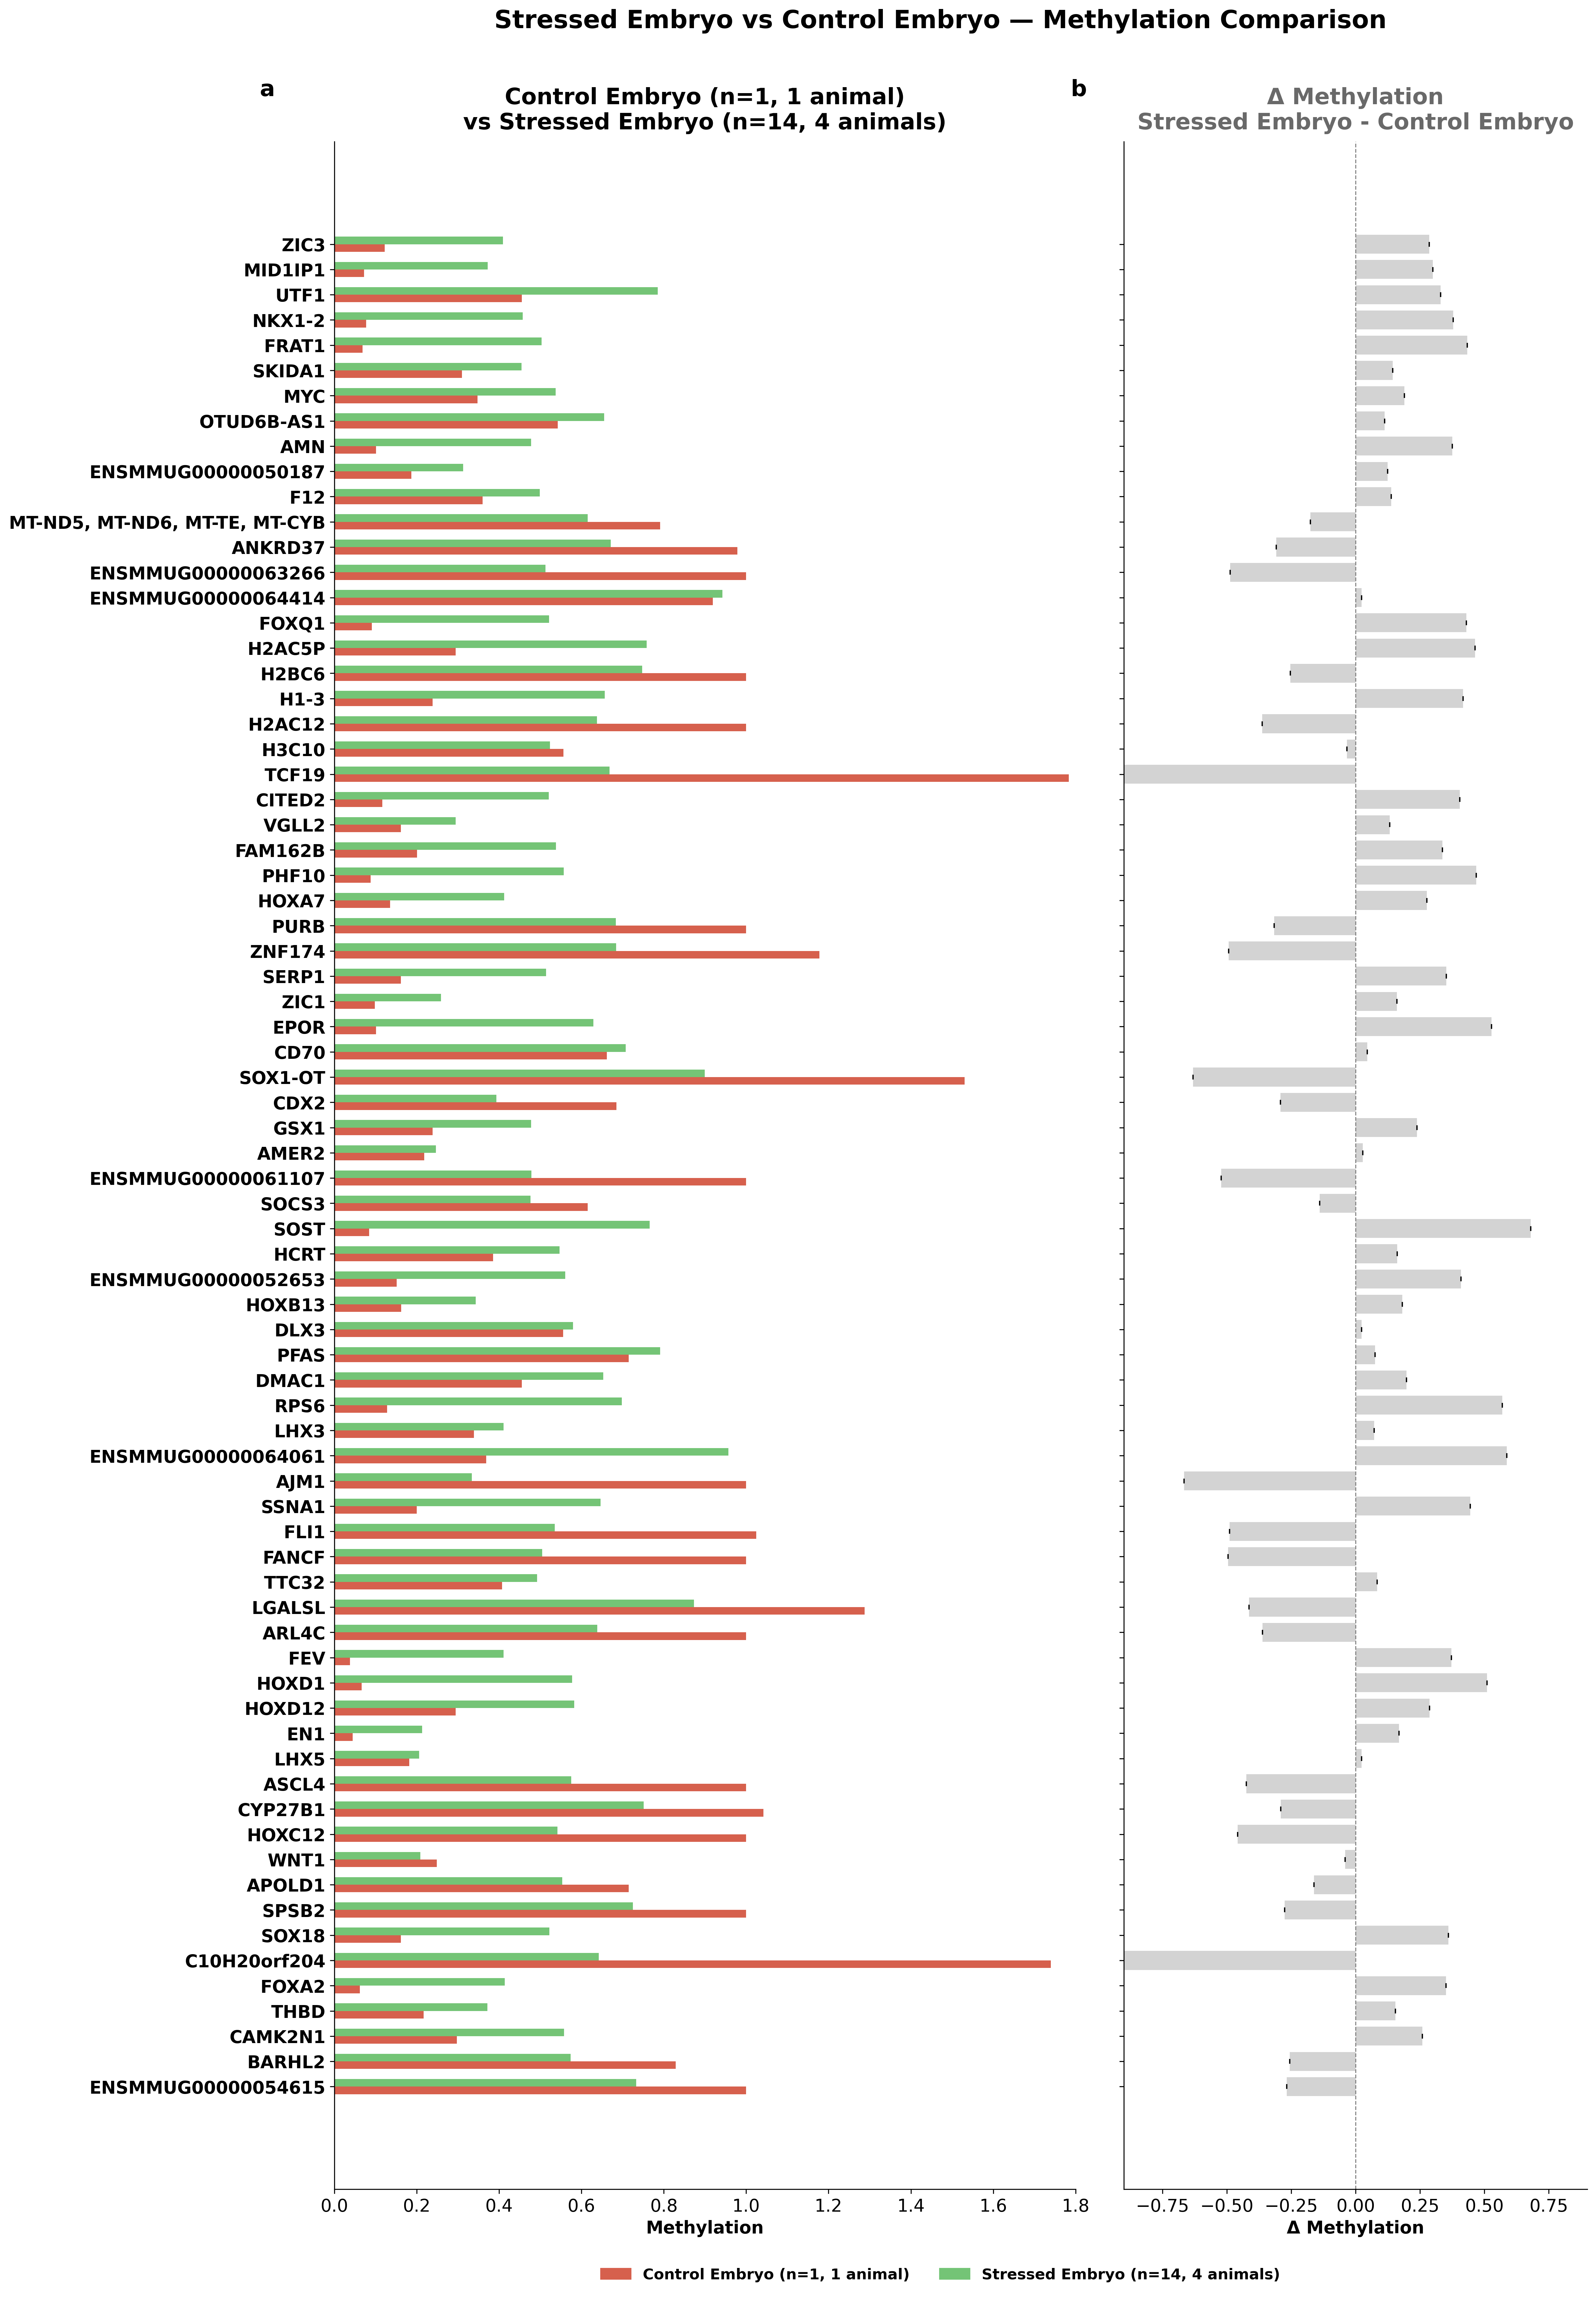

Saved: figure6-v2/stressed_vs_control_embryo
Saved stats: figure6-v2/stressed_vs_control_embryo_stats.csv
Done.


In [19]:
# ============================================================
# Title: Stressed embryo vs control embryo only (built-in Welch test)
# What changed/added:
# 1) Removed all per-animal embryo vs oocyte sections
# 2) Kept only stressed embryo vs control embryo comparison
# 3) Replaced manual Welch t-test + CI with statsmodels CompareMeans
# 4) Handles non-estimable comparisons with NaN
# 5) Applies BH FDR correction only to valid p-values
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans

# ── Helpers ──────────────────────────────────────────────────────────────────

def to_dense(adata):
    X = adata.layers['methylation_fraction']
    return X.toarray() if hasattr(X, 'toarray') else np.array(X)

def welch_statsmodels(a, b, alpha=0.05):
    """
    Returns (pval, delta, ci_low, ci_high) for b - a
    using built-in Welch t-test from statsmodels.
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]

    if len(a) == 0 or len(b) == 0:
        return np.nan, np.nan, np.nan, np.nan

    delta = np.mean(b) - np.mean(a)

    # CI/test not estimable with <2 observations in either group
    if len(a) < 2 or len(b) < 2:
        return np.nan, delta, np.nan, np.nan

    # Degenerate case: both groups constant
    if (np.std(a, ddof=1) == 0) and (np.std(b, ddof=1) == 0):
        return 1.0, delta, delta, delta

    cm = CompareMeans(DescrStatsW(b), DescrStatsW(a))
    tstat, pval, df = cm.ttest_ind(usevar='unequal')
    ci_lo, ci_hi = cm.tconfint_diff(usevar='unequal', alpha=alpha)

    return pval, delta, ci_lo, ci_hi

def pval_to_stars(p):
    if pd.isna(p):
        return ''
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return ''

def get_color(is_sig, is_tf):
    if is_sig and is_tf:
        return 'red'
    if is_sig:
        return 'orange'
    return 'lightgray'

def subset_ordered(adata, ids):
    vdf = adata.var.reset_index().drop_duplicates('gene_id').set_index('gene_id')
    return adata[:, vdf.loc[ids]['index'].values].copy()

def add_panel_label(ax, label, fontsize=18):
    ax.text(
        -0.08, 1.02, label,
        transform=ax.transAxes,
        fontsize=fontsize,
        fontweight='bold',
        va='bottom',
        ha='right'
    )

def add_stars(ax, adf, delta_col, ci_lo_col, ci_hi_col, fdr_col):
    for i, (_, row) in enumerate(adf.iterrows()):
        stars = pval_to_stars(row[fdr_col])
        if stars and pd.notna(row[ci_lo_col]) and pd.notna(row[ci_hi_col]):
            x_pos = row[ci_hi_col] if row[delta_col] >= 0 else row[ci_lo_col]
            offset = 0.005 if row[delta_col] >= 0 else -0.005
            ax.text(
                x_pos + offset, i, stars,
                va='center',
                ha='left' if row[delta_col] >= 0 else 'right',
                fontsize=14,
                fontweight='bold',
                color='black'
            )

# ── Gene metadata ─────────────────────────────────────────────────────────────

highlight_tfs_set = set([
    'BARHL2', 'FOXA2', 'SOX18', 'HOXC12', 'ASCL4', 'LHX5', 'EN1',
    'HOXD12', 'HOXD1', 'FEV', 'LHX3', 'DLX3', 'HOXB13', 'GSX1',
    'CDX2', 'ZIC1', 'ZNF174', 'PURB', 'HOXA7', 'VGLL2', 'CITED2',
    'TCF19', 'FOXQ1', 'MYC', 'NKX1-2', 'FLI1', 'UTF1', 'ZIC3'
])

genes_df = pd.read_csv("../pooledoocytes/mCG_genenames_coords_withlifted.csv", sep=",")
genes_df.columns = ["gene_id", "chr", "start", "end", "genename"]
target_genes = genes_df['gene_id'].dropna().unique()
target_genes_set = set(target_genes)
gene_id_to_name = (
    genes_df.dropna(subset=['genename'])
    .set_index("gene_id")["genename"]
    .to_dict()
)

# Use group-level order if meth_df exists; otherwise use file order
try:
    gene_order = meth_df['genename'].tolist()
except NameError:
    gene_order = (
        genes_df['genename']
        .dropna()
        .astype(str)
        .drop_duplicates()
        .tolist()
    )

emb_color = '#74C476'       # stressed embryo
ctrl_emb_color = '#D6604D'  # control embryo

TITLE_FS = 18
LABEL_FS = 14
TICK_FS = 14
GENE_FS = 14

os.makedirs("figure6-v2", exist_ok=True)

# ═══════════════════════════════════════════════════════════════════════════════
# Stressed Embryo vs Control Embryo
# ═══════════════════════════════════════════════════════════════════════════════

print("Building stressed embryo vs control embryo figure...")

adata_emb_stressed = adataembryo[adataembryo.obs['Group'] == 'Stressed'].copy()
adata_emb_control  = adataembryo[adataembryo.obs['Group'] == 'Control'].copy()

n_str_emb_cells = adata_emb_stressed.shape[0]
n_ctrl_emb_cells = adata_emb_control.shape[0]
n_str_emb_animals = adata_emb_stressed.obs['AnimalID'].nunique()
n_ctrl_emb_animals = adata_emb_control.obs['AnimalID'].nunique()

print(f"  Stressed embryo: {n_str_emb_cells} cells, {n_str_emb_animals} animal(s)")
print(f"  Control embryo:  {n_ctrl_emb_cells} cells, {n_ctrl_emb_animals} animal(s)")

# Filter to target genes
adata_emb_stressed = adata_emb_stressed[:, adata_emb_stressed.var['gene_id'].isin(target_genes_set)].copy()
adata_emb_control  = adata_emb_control[:,  adata_emb_control.var['gene_id'].isin(target_genes_set)].copy()

# Align common genes in target order
str_ids = set(adata_emb_stressed.var['gene_id'])
ctrl_ids = set(adata_emb_control.var['gene_id'])
common = [g for g in target_genes if g in str_ids and g in ctrl_ids]

if len(common) == 0:
    raise ValueError("No common target genes found between stressed and control embryo datasets.")

adata_emb_stressed = subset_ordered(adata_emb_stressed, common)
adata_emb_control  = subset_ordered(adata_emb_control, common)

X_str = to_dense(adata_emb_stressed)
X_ctrl = to_dense(adata_emb_control)

results = []
for i, gid in enumerate(common):
    gname = gene_id_to_name.get(gid, gid)

    str_vals = X_str[:, i]
    ctrl_vals = X_ctrl[:, i]

    # delta = stressed embryo - control embryo
    p, d, ci_lo, ci_hi = welch_statsmodels(ctrl_vals, str_vals)

    results.append({
        'gene_id': gid,
        'genename': gname,
        'ctrl_embryo_mean': np.mean(ctrl_vals),
        'str_embryo_mean': np.mean(str_vals),
        'delta': d,
        'ci_lo': ci_lo,
        'ci_hi': ci_hi,
        'pval': p,
    })

edf = pd.DataFrame(results)

# FDR only on valid p-values
edf['fdr'] = np.nan
valid_mask = edf['pval'].notna()
if valid_mask.sum() > 0:
    edf.loc[valid_mask, 'fdr'] = multipletests(edf.loc[valid_mask, 'pval'], method='fdr_bh')[1]

edf['significant'] = (edf['fdr'] < 0.05) & (edf['delta'].abs() > 0.05)
edf['is_tf'] = edf['genename'].isin(highlight_tfs_set)

edf = edf[edf['genename'].isin(gene_order)].copy()
edf['genename'] = pd.Categorical(edf['genename'], categories=gene_order, ordered=True)
edf = edf.sort_values('genename').reset_index(drop=True)

if len(edf) == 0:
    raise ValueError("No genes left after applying gene order filter.")

# Save stats table
edf.to_csv("figure6-v2/stressed_vs_control_embryo_stats.csv", index=False)

bar_colors_emb = [get_color(r['significant'], r['is_tf']) for _, r in edf.iterrows()]

n_genes_plot = len(edf)
fig_height = max(12, 0.4 * n_genes_plot)

fig, axes = plt.subplots(
    1, 2,
    figsize=(18, fig_height),
    sharey=True,
    gridspec_kw={'wspace': 0.08, 'width_ratios': [1.6, 1]}
)

gene_names = edf['genename'].tolist()
y_pos = np.arange(n_genes_plot)
bar_w = 0.3
abs_max = max(edf['str_embryo_mean'].max(), edf['ctrl_embryo_mean'].max())
abs_xlim = np.ceil(abs_max * 10) / 10

# Panel A – side-by-side control vs stressed embryo
ax = axes[0]
ax.barh(
    y_pos - bar_w/2,
    edf['ctrl_embryo_mean'],
    height=bar_w,
    color=ctrl_emb_color,
    edgecolor='none'
)
ax.barh(
    y_pos + bar_w/2,
    edf['str_embryo_mean'],
    height=bar_w,
    color=emb_color,
    edgecolor='none'
)
ax.set_xlim(0, abs_xlim)
ax.set_xlabel('Methylation', fontsize=LABEL_FS, fontweight='bold')
ax.set_title(
    f'Control Embryo (n={n_ctrl_emb_cells}, {n_ctrl_emb_animals} animal'
    f'{"s" if n_ctrl_emb_animals != 1 else ""})\n'
    f'vs Stressed Embryo (n={n_str_emb_cells}, {n_str_emb_animals} animal'
    f'{"s" if n_str_emb_animals != 1 else ""})',
    fontsize=TITLE_FS,
    fontweight='bold',
    pad=10
)
ax.set_yticks(y_pos)
ax.set_yticklabels(gene_names, fontsize=GENE_FS, fontweight='bold')
ax.axvline(0, color='gray', linewidth=0.5)
ax.invert_yaxis()
add_panel_label(ax, 'a')

# Panel B – Δ stressed embryo vs control embryo
ax = axes[1]
xerr_lo = (edf['delta'] - edf['ci_lo']).fillna(0)
xerr_hi = (edf['ci_hi'] - edf['delta']).fillna(0)

ax.barh(
    y_pos,
    edf['delta'],
    xerr=[xerr_lo, xerr_hi],
    color=bar_colors_emb,
    edgecolor='none',
    height=0.75,
    error_kw=dict(ecolor='black', capsize=2, linewidth=0.8)
)
ax.axvline(0, linestyle='--', color='gray', linewidth=0.8)
ax.set_xlim(-0.9, 0.9)
ax.set_xlabel('Δ Methylation', fontsize=LABEL_FS, fontweight='bold')
ax.set_title(
    f'Δ Methylation\nStressed Embryo - Control Embryo',
    fontsize=TITLE_FS,
    fontweight='bold',
    pad=10,
    color='dimgray' if n_ctrl_emb_animals == 1 else 'black'
)
add_stars(ax, edf, 'delta', 'ci_lo', 'ci_hi', 'fdr')
ax.invert_yaxis()
add_panel_label(ax, 'b')

for ax in axes:
    ax.tick_params(axis='x', labelsize=TICK_FS)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

legend_patches = [
    #mpatches.Patch(color='red', label='Significant TF'),
    #mpatches.Patch(color='orange', label='Significant gene'),
    #mpatches.Patch(color='lightgray', label='Non-significant gene'),
    mpatches.Patch(
        color=ctrl_emb_color,
        label=f'Control Embryo (n={n_ctrl_emb_cells}, {n_ctrl_emb_animals} animal'
              f'{"s" if n_ctrl_emb_animals != 1 else ""})'
    ),
    mpatches.Patch(
        color=emb_color,
        label=f'Stressed Embryo (n={n_str_emb_cells}, {n_str_emb_animals} animal'
              f'{"s" if n_str_emb_animals != 1 else ""})'
    ),
]
fig.legend(
    handles=legend_patches,
    loc='lower center',
    ncol=5,
    prop={'size': 12, 'weight': 'bold'},
    frameon=False,
    bbox_to_anchor=(0.5, 0.07)
)

plt.suptitle(
    "Stressed Embryo vs Control Embryo — Methylation Comparison",
    fontsize=20,
    fontweight='bold',
    y=0.93
)
plt.tight_layout(rect=[0, 0.04, 1, 1])

fname = "figure6-v2/stressed_vs_control_embryo"
plt.savefig(fname + ".pdf", bbox_inches='tight')
#plt.savefig(fname + ".png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {fname}")
print("Saved stats: figure6-v2/stressed_vs_control_embryo_stats.csv")
print("Done.")

In [32]:
# ============================================================
# Title: Per-animal embryo vs oocyte methylation using statsmodels Welch test
# What changed/added:
# 1) Replaced manual Welch t-test + CI with statsmodels CompareMeans
# 2) Added Cohen's d and Hedges' g to results
# 3) Kept raw delta (Embryo - Oocyte) and CI for plotting
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from statsmodels.stats.multitest import multipletests
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans
from statsmodels.stats.meta_analysis import effectsize_smd

# ── Helpers ──────────────────────────────────────────────────────────────────

def to_dense(adata):
    X = adata.layers['methylation_fraction']
    return X.toarray() if hasattr(X, 'toarray') else np.array(X)

def welch_statsmodels(a, b, alpha=0.05):
    """
    Welch two-sample test using statsmodels.

    Returns
    -------
    pval : float
        Two-sided Welch t-test p-value
    delta : float
        Raw mean difference = mean(b) - mean(a)
    ci_lo, ci_hi : float
        Confidence interval for raw mean difference
    cohen_d : float
        Standardized mean difference
    hedges_g : float
        Small-sample corrected standardized mean difference
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]

    if len(a) == 0 or len(b) == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

    delta = np.mean(b) - np.mean(a)

    if len(a) < 2 or len(b) < 2:
        return 1.0, delta, delta, delta, np.nan, np.nan

    if np.std(a, ddof=1) == 0 and np.std(b, ddof=1) == 0:
        return 1.0, delta, delta, delta, np.nan, np.nan

    cm = CompareMeans(DescrStatsW(b), DescrStatsW(a))

    # Welch t-test
    tstat, pval, df = cm.ttest_ind(usevar='unequal')

    # CI for raw mean difference: mean(b) - mean(a)
    ci_lo, ci_hi = cm.tconfint_diff(usevar='unequal', alpha=alpha)

    # Hedges' g from statsmodels meta-analysis helper
    hedges_g, _ = effectsize_smd(
        mean1=np.mean(b), sd1=np.std(b, ddof=1), nobs1=len(b),
        mean2=np.mean(a), sd2=np.std(a, ddof=1), nobs2=len(a)
    )

    # Convert g to approximate Cohen's d
    total_n = len(a) + len(b)
    J = 1 - (3 / (4 * total_n - 9)) if (4 * total_n - 9) != 0 else np.nan
    cohen_d = hedges_g / J if np.isfinite(J) and J != 0 else np.nan

    return pval, delta, ci_lo, ci_hi, cohen_d, hedges_g

def pval_to_stars(p):
    if pd.isna(p):
        return ''
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return ''

def get_color(is_sig, is_tf):
    if is_sig and is_tf:
        return 'red'
    if is_sig:
        return 'orange'
    return 'lightgray'

def subset_ordered(adata, ids):
    vdf = adata.var.reset_index().drop_duplicates('gene_id').set_index('gene_id')
    return adata[:, vdf.loc[ids]['index'].values].copy()

def add_stars(ax, adf, delta_col, ci_lo_col, ci_hi_col, fdr_col):
    for i, (_, row) in enumerate(adf.iterrows()):
        stars = pval_to_stars(row[fdr_col])
        if stars:
            x_pos = row[ci_hi_col] if row[delta_col] >= 0 else row[ci_lo_col]
            offset = 0.000 if row[delta_col] >= 0 else -0.005
            ax.text(
                x_pos + offset, i, stars,
                va='center',
                ha='left' if row[delta_col] >= 0 else 'right',
                fontsize=18,
                fontweight='bold',
                color='black'
            )

# ── Gene metadata ─────────────────────────────────────────────────────────────

highlight_tfs_set = set([
    'BARHL2', 'FOXA2', 'SOX18', 'HOXC12', 'ASCL4', 'LHX5', 'EN1',
    'HOXD12', 'HOXD1', 'FEV', 'LHX3', 'DLX3', 'HOXB13', 'GSX1',
    'CDX2', 'ZIC1', 'ZNF174', 'PURB', 'HOXA7', 'VGLL2', 'CITED2',
    'TCF19', 'FOXQ1', 'MYC', 'NKX1-2', 'FLI1', 'UTF1', 'ZIC3'
])

genes_df = pd.read_csv("../pooledoocytes/mCG_genenames_coords_withlifted.csv", sep=",")
genes_df.columns = ["gene_id", "chr", "start", "end", "genename"]
target_genes = genes_df['gene_id'].dropna().unique()
target_genes_set = set(target_genes)
gene_id_to_name = genes_df.dropna(subset=['genename']).set_index("gene_id")["genename"].to_dict()

gene_order = meth_df['genename'].tolist()

ooc_color = '#4393C3'
emb_color = '#74C476'
TITLE_FS = 20
LABEL_FS = 18
TICK_FS = 15
GENE_FS = 18

# ── Sort animals: stressed first, then control ────────────────────────────────

oocyte_animals = set(adataoocyte.obs['AnimalID'].unique())
embryo_animals = set(adataembryo.obs['AnimalID'].unique())
paired_animals = sorted(oocyte_animals & embryo_animals)

def get_group(animal_id):
    obs = adataoocyte[adataoocyte.obs['AnimalID'] == animal_id].obs
    return obs['Group'].iloc[0] if len(obs) > 0 else 'Unknown'

animal_groups = {a: get_group(a) for a in paired_animals}
stressed_first = (
    sorted([a for a in paired_animals if animal_groups[a] == 'Stressed']) +
    sorted([a for a in paired_animals if animal_groups[a] != 'Stressed'])
)
print(f"Animal order: {stressed_first}")

# ── Pre-compute per-animal data ───────────────────────────────────────────────

animal_data = {}
all_stats_list = []

for animal_id in stressed_first:
    ooc_a = adataoocyte[adataoocyte.obs['AnimalID'] == animal_id].copy()
    emb_a = adataembryo[adataembryo.obs['AnimalID'] == animal_id].copy()

    ooc_a = ooc_a[:, ooc_a.var['gene_id'].isin(target_genes_set)].copy()
    emb_a = emb_a[:, emb_a.var['gene_id'].isin(target_genes_set)].copy()

    ooc_ids = set(ooc_a.var['gene_id'])
    emb_ids = set(emb_a.var['gene_id'])
    common = [g for g in target_genes if g in ooc_ids and g in emb_ids]

    if len(common) == 0:
        print(f"Skipping {animal_id}: no common genes.")
        continue

    ooc_a = subset_ordered(ooc_a, common)
    emb_a = subset_ordered(emb_a, common)

    X_ooc = to_dense(ooc_a)
    X_emb = to_dense(emb_a)
    n_ooc = X_ooc.shape[0]
    n_emb = X_emb.shape[0]

    results = []
    for i, gid in enumerate(common):
        gname = gene_id_to_name.get(gid, gid)
        ooc_vals = X_ooc[:, i]
        emb_vals = X_emb[:, i]

        p, d, ci_lo, ci_hi, cohen_d, hedges_g = welch_statsmodels(ooc_vals, emb_vals)

        results.append({
            'animal_id': animal_id,
            'group': animal_groups[animal_id],
            'gene_id': gid,
            'genename': gname,
            'n_oocyte_cells': len(ooc_vals),
            'n_embryo_cells': len(emb_vals),
            'oocyte_mean': np.mean(ooc_vals),
            'embryo_mean': np.mean(emb_vals),
            'delta': d,
            'ci_lo': ci_lo,
            'ci_hi': ci_hi,
            'pval': p,
            'cohen_d': cohen_d,
            'hedges_g': hedges_g,
        })

    adf = pd.DataFrame(results)

    valid_mask = adf['pval'].notna()
    adf['fdr'] = np.nan
    if valid_mask.sum() > 0:
        adf.loc[valid_mask, 'fdr'] = multipletests(adf.loc[valid_mask, 'pval'], method='fdr_bh')[1]

    adf['significant'] = (adf['fdr'] < 0.05) & (adf['delta'].abs() > 0.05)
    adf['is_tf'] = adf['genename'].isin(highlight_tfs_set)

    adf = adf[adf['genename'].isin(gene_order)].copy()
    adf['genename'] = pd.Categorical(adf['genename'], categories=gene_order, ordered=True)
    adf = adf.sort_values('genename').reset_index(drop=True)

    animal_data[animal_id] = {
        'adf': adf,
        'n_ooc': n_ooc,
        'n_emb': n_emb,
        'group': animal_groups[animal_id]
    }

    all_stats_list.append(adf.copy())

valid_animals = [a for a in stressed_first if a in animal_data]
n_animals = len(valid_animals)

if n_animals == 0:
    raise ValueError("No valid paired animals found after filtering.")

n_genes_plot = len(animal_data[valid_animals[0]]['adf'])

# Save combined stats table
os.makedirs("figure6-v2/per_animal", exist_ok=True)
all_stats_df = pd.concat(all_stats_list, axis=0, ignore_index=True)
all_stats_df.to_csv("figure6-v2/per_animal/per_animal_embryo_vs_oocyte_stats.csv", index=False)

# ── Build figure: 1 row × (n_animals * 2) columns ────────────────────────────

gene_col_w = 2.5
abs_col_w = 2.5
delta_col_w = 2.0
gap_within = 0.04
gap_between = 0.18

row_height = 0.4
fig_height = max(12, row_height * n_genes_plot)

fig_width = 32 #gene_col_w + (abs_col_w + delta_col_w) * (n_animals - 1) + abs_col_w + delta_col_w
fig = plt.figure(figsize=(fig_width, fig_height))

outer_gs = fig.add_gridspec(
    1, n_animals,
    wspace=0.20,
    width_ratios=[
        (gene_col_w + abs_col_w) / (abs_col_w + delta_col_w) if i == 0 else 1.0
        for i in range(n_animals)
    ]
)

axes_abs = []
axes_delta = []

for a_idx in range(n_animals):
    inner_gs = outer_gs[a_idx].subgridspec(
        1, 2,
        wspace=gap_within,
        width_ratios=[
            (gene_col_w / delta_col_w) if a_idx == 0 else (abs_col_w / delta_col_w),
            1.0
        ]
    )
    axes_abs.append(fig.add_subplot(inner_gs[0]))
    axes_delta.append(fig.add_subplot(inner_gs[1]))

y_pos = np.arange(n_genes_plot)

all_abs_max = max(
    max(d['adf']['oocyte_mean'].max(), d['adf']['embryo_mean'].max())
    for d in animal_data.values()
)
abs_xlim = np.ceil(all_abs_max * 10) / 10

# ── Fill panels ───────────────────────────────────────────────────────────────

for a_idx, animal_id in enumerate(valid_animals):
    d = animal_data[animal_id]
    adf = d['adf']
    n_ooc = d['n_ooc']
    n_emb = d['n_emb']
    group = d['group']
    show_genes = (a_idx == 0)
    bar_colors = [get_color(r['significant'], r['is_tf']) for _, r in adf.iterrows()]
    bar_w = 0.35
    group_color = '#C0392B' if group == 'Stressed' else '#2471A3'

    # ── Absolute methylation panel ──
    ax = axes_abs[a_idx]
    ax.barh(y_pos - bar_w/2, adf['oocyte_mean'], height=bar_w, color=ooc_color, edgecolor='none')
    ax.barh(y_pos + bar_w/2, adf['embryo_mean'], height=bar_w, color=emb_color, edgecolor='none')
    ax.set_xlim(0, abs_xlim)
    ax.set_ylim(n_genes_plot - 0.5, -0.5)
    ax.set_xlabel('Methylation', fontsize=LABEL_FS, fontweight='bold')
    ax.set_title(
        f'Animal {animal_id} - {group}\noocyte n={n_ooc} | embryo n={n_emb}',
        fontsize=TITLE_FS, fontweight='bold', color=group_color, pad=6
    )
    ax.axvline(0, color='gray', linewidth=0.4)
    ax.set_yticks(y_pos)

    if show_genes:
        ax.set_yticklabels(adf['genename'].tolist(), fontsize=GENE_FS, fontweight='bold')
        ax.tick_params(axis='y', left=True, labelleft=True)
    else:
        ax.set_yticklabels([])
        ax.tick_params(axis='y', left=False, labelleft=False)

    ax.tick_params(axis='x', labelsize=TICK_FS)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    panel_label = chr(ord('a') + a_idx)
    ax.text(
        -0.05 if show_genes else -0.03, 1.02, panel_label,
        transform=ax.transAxes, fontsize=24, fontweight='bold',
        va='bottom', ha='right'
    )

    # ── Delta panel ──
    ax = axes_delta[a_idx]
    xerr_lo = adf['delta'] - adf['ci_lo']
    xerr_hi = adf['ci_hi'] - adf['delta']

    ax.barh(
        y_pos, adf['delta'],
        xerr=[xerr_lo, xerr_hi],
        color=bar_colors, edgecolor='none', height=0.75,
        error_kw=dict(ecolor='black', capsize=2, linewidth=0.7)
    )
    ax.axvline(0, linestyle='--', color='gray', linewidth=0.7)
    ax.set_xlim(-0.9, 0.9)
    ax.set_ylim(n_genes_plot - 0.5, -0.5)
    ax.set_xlabel('Δ Methylation', fontsize=LABEL_FS, fontweight='bold')
    ax.set_title(
        'Δ Methylation\nEmbryo - Oocyte',
        fontsize=TITLE_FS, fontweight='bold',
        color=group_color, pad=6
    )
    add_stars(ax, adf, 'delta', 'ci_lo', 'ci_hi', 'fdr')
    ax.set_yticks(y_pos)
    ax.set_yticklabels([])
    ax.tick_params(axis='y', left=False, labelleft=False)
    ax.tick_params(axis='x', labelsize=TICK_FS)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Legend ────────────────────────────────────────────────────────────────────

legend_patches = [
    mpatches.Patch(color='red', label='Significant TF'),
    mpatches.Patch(color='orange', label='Significant gene'),
    mpatches.Patch(color='lightgray', label='Non-significant gene'),
    mpatches.Patch(color=ooc_color, label='Oocyte'),
    mpatches.Patch(color=emb_color, label='Embryo'),
]

fig.legend(
    handles=legend_patches,
    loc='lower center',
    ncol=5,
    prop={'size': 22, 'weight': 'bold'},
    frameon=False,
    bbox_to_anchor=(0.5, 0.06)
)

plt.suptitle(
    "Per-Animal Embryo vs Oocyte Methylation",
    fontsize=28, fontweight='bold', y=0.93
)

fig.tight_layout()

fname = "figure6-v2/per_animal/all_animals_combined_inArow"
plt.savefig(fname + ".pdf", bbox_inches='tight')
#plt.savefig(fname + ".png", bbox_inches='tight', dpi=300)
plt.show()

print(f"Saved: {fname}")
print("Saved stats table: figure6-v2/per_animal/per_animal_embryo_vs_oocyte_stats.csv")

Animal order: [41299, 45208, 42111]


/tmp/ipykernel_4033095/2748659262.py:390: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: figure6-v2/per_animal/all_animals_combined_inArow
Saved stats table: figure6-v2/per_animal/per_animal_embryo_vs_oocyte_stats.csv
